In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

# Aqui cargamos el archivo desde Drive
df = pd.read_csv('/content/drive/MyDrive/denuncias_policiales.csv', encoding='latin-1', sep=',')

# 1. Ver las dimensiones exactas (Filas y Columnas)
print("Dimensiones del dataset:", df.shape)

# 2. Ver el tipo de datos y si hay nulos
print("\nInformación general de las columnas:")
df.info()

# 3. Ver las primeras 5 filas
display(df.head())

# 4. Ver los tipos de delitos usando la columna correcta
print("\nDistribución de la variable objetivo (Tipos de delitos):")
print(df['P_MODALIDADES'].value_counts())

Dimensiones del dataset: (369100, 8)

Información general de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369100 entries, 0 to 369099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ANIO            369100 non-null  int64 
 1   MES             369100 non-null  int64 
 2   DPTO_HECHO_NEW  369100 non-null  object
 3   PROV_HECHO      369100 non-null  object
 4   DIST_HECHO      369100 non-null  object
 5   UBIGEO_HECHO    369100 non-null  int64 
 6   P_MODALIDADES   369100 non-null  object
 7   cantidad        369100 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 22.5+ MB


,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
0,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Otros,4
1,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Violencia contra la mujer e integrantes,3
2,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Estafa,2
3,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Hurto,25
4,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Otros,52



Distribución de la variable objetivo (Tipos de delitos):
P_MODALIDADES
Otros                                      107429
Violencia contra la mujer e integrantes     94941
Hurto                                       67438
Robo                                        41751
Estafa                                      31004
ExtorsiÃ³n                                  19527
Secuestro                                    7010
Name: count, dtype: int64


In [4]:
# Evaluar Completitud (Nulos) y Unicidad (Duplicados)
total_nulos = df.isnull().sum().sum()
total_duplicados = df.duplicated().sum()

print(f"Total de valores faltantes (Nulos): {total_nulos}")
print(f"Total de registros duplicados: {total_duplicados}")

# Aqui si es que hay duplicados, los eliminamos para tener los datos limpios
if total_duplicados > 0:
    df = df.drop_duplicates()
    print(f"Se eliminaron los duplicados. Nuevo tamaño del dataset: {df.shape[0]} registros.")

Total de valores faltantes (Nulos): 0
Total de registros duplicados: 0


/tmp/ipykernel_836/1530031650.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico_modalidades = sns.barplot(


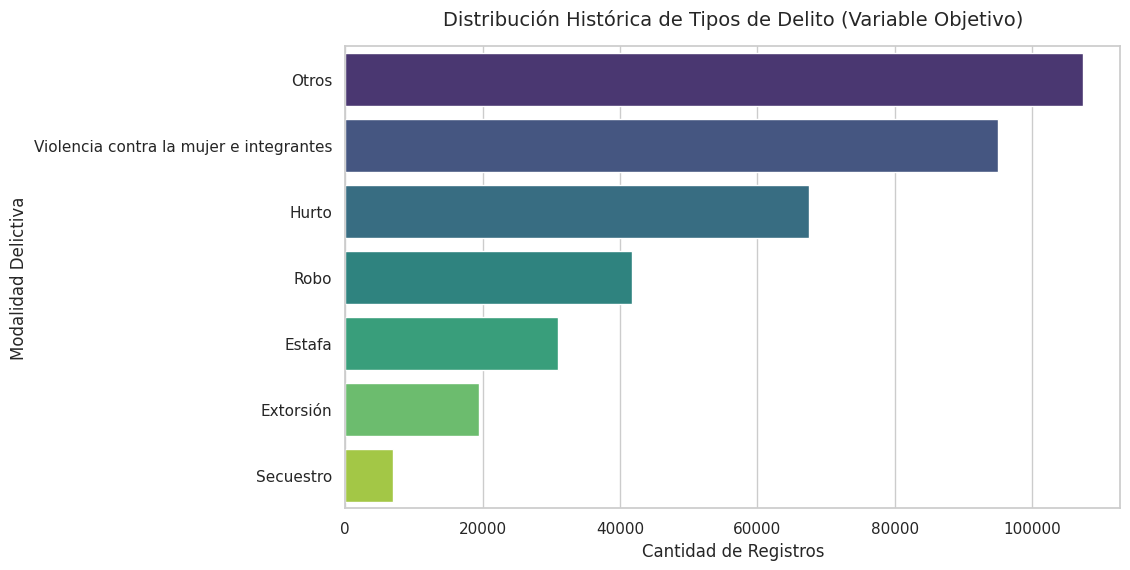

/tmp/ipykernel_836/1530031650.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


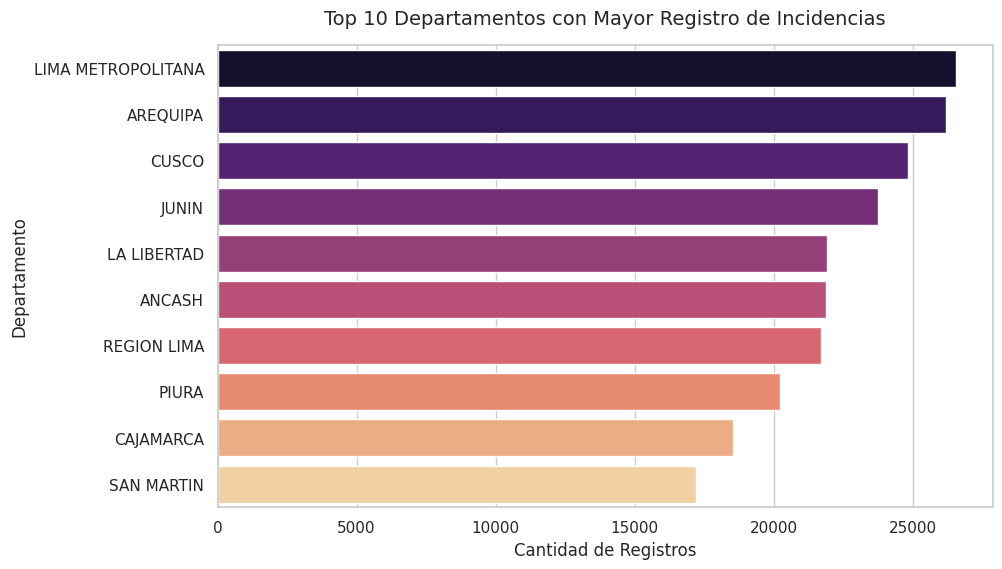

/tmp/ipykernel_836/1530031650.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


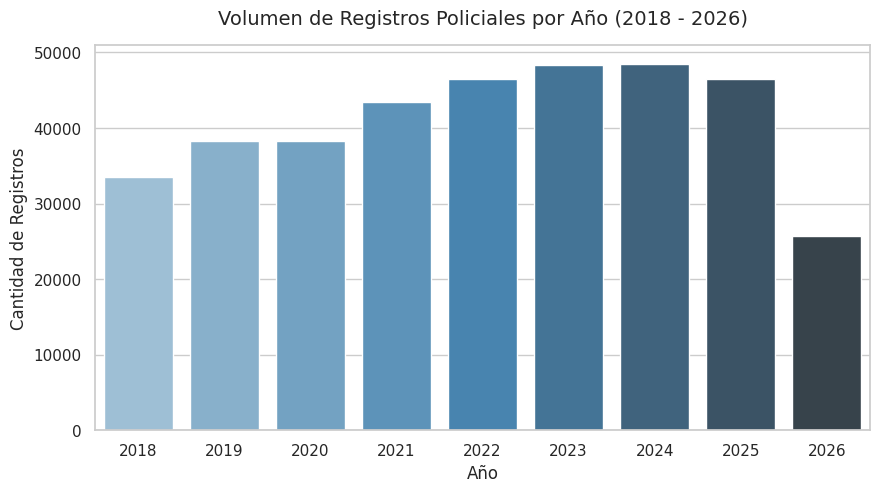

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aca se hace la impieza de caracteres extraños en la variable objetivo
df['P_MODALIDADES'] = df['P_MODALIDADES'].replace('ExtorsiÃ³n', 'Extorsión')

# Configuración de estilo visual para los gráficos
sns.set_theme(style="whitegrid")

# 2. GRÁFICO 1: Distribución de la variable objetivo (Tipos de Delito)
plt.figure(figsize=(10, 6))
grafico_modalidades = sns.barplot(
    y=df['P_MODALIDADES'].value_counts().index,
    x=df['P_MODALIDADES'].value_counts().values,
    palette="viridis"
)
plt.title('Distribución Histórica de Tipos de Delito (Variable Objetivo)', fontsize=14, pad=15)
plt.xlabel('Cantidad de Registros', fontsize=12)
plt.ylabel('Modalidad Delictiva', fontsize=12)
plt.show()

# 3. GRÁFICO 2: Top 10 Departamentos con más registros de denuncias
plt.figure(figsize=(10, 6))
top_dptos = df['DPTO_HECHO_NEW'].value_counts().head(10)
sns.barplot(
    y=top_dptos.index,
    x=top_dptos.values,
    palette="magma"
)
plt.title('Top 10 Departamentos con Mayor Registro de Incidencias', fontsize=14, pad=15)
plt.xlabel('Cantidad de Registros', fontsize=12)
plt.ylabel('Departamento', fontsize=12)
plt.show()

# 4. GRÁFICO 3: Evolución de registros por Año
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='ANIO',
    palette="Blues_d"
)
plt.title('Volumen de Registros Policiales por Año (2018 - 2026)', fontsize=14, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score

print("Iniciando Pipeline de Datos y Modelado...\n")

# 1. PREPARACIÓN E INGENIERÍA DE DATOS
df_ml = df.copy()
le_dpto, le_prov, le_dist, le_target = LabelEncoder(), LabelEncoder(), LabelEncoder(), LabelEncoder()

df_ml['DPTO_HECHO_NEW'] = le_dpto.fit_transform(df_ml['DPTO_HECHO_NEW'])
df_ml['PROV_HECHO'] = le_prov.fit_transform(df_ml['PROV_HECHO'])
df_ml['DIST_HECHO'] = le_dist.fit_transform(df_ml['DIST_HECHO'])
df_ml['P_MODALIDADES'] = le_target.fit_transform(df_ml['P_MODALIDADES'])

# Eliminar 'cantidad' para evitar Data Leakage
X = df_ml.drop(columns=['P_MODALIDADES', 'cantidad'])
y = df_ml['P_MODALIDADES']

# Train/Test Split (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. MODELO BASE (BASELINE) - Regresión Logística
print(" Entrenando Modelo Base (Regresión Logística) ")
# Usamos class_weight='balanced' para ayudar con el desbalance de los delitos
modelo_base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_base.fit(X_train_scaled, y_train)
y_pred_base = modelo_base.predict(X_test_scaled)
print("F1-Score (Macro) Baseline:", f1_score(y_test, y_pred_base, average='macro'))

# 3. MODELO AVANZADO - KNN (K=1)
print("\n Entrenando Modelo Avanzado (KNN)")
# Usamos K=1 porque demostró ser el óptimo para evitar sesgos
knn_optimo = KNeighborsClassifier(n_neighbors=1)
knn_optimo.fit(X_train_scaled, y_train)
y_pred_knn = knn_optimo.predict(X_test_scaled)
print("F1-Score (Macro) KNN:", f1_score(y_test, y_pred_knn, average='macro'))

print("\n Modelos entrenados con éxito.")

Iniciando Pipeline de Datos y Modelado...

 Entrenando Modelo Base (Regresión Logística) 
F1-Score (Macro) Baseline: 0.130676790215748

 Entrenando Modelo Avanzado (KNN)
F1-Score (Macro) KNN: 0.024496817072931963

 Modelos entrenados con éxito.


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import pandas as pd

print(" Entrenando Modelo Avanzado 2 (Random Forest) ")
# Usamos n_estimators=50 para que sea rápido y class_weight='balanced' para el desbalance
rf_modelo = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)
rf_modelo.fit(X_train_scaled, y_train)
y_pred_rf = rf_modelo.predict(X_test_scaled)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print("F1-Score (Macro) Random Forest:", f1_rf)

print("\n Generando Tabla Comparativa Final ")
# Creamos la tabla de resultados
resultados = {
    'Modelo': ['Regresión Logística (Baseline)', 'K-Nearest Neighbors (K=1)', 'Random Forest (Tuned)'],
    'F1-Score (Macro)': [0.1306, 0.0244, f1_rf]
}
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

 Entrenando Modelo Avanzado 2 (Random Forest) 
F1-Score (Macro) Random Forest: 0.03705296105391218

 Generando Tabla Comparativa Final 


,Modelo,F1-Score (Macro)
0,Regresión Logística (Baseline),0.130600
1,K-Nearest Neighbors (K=1),0.024400
2,Random Forest (Tuned),0.037053


 Generando Gráficos 


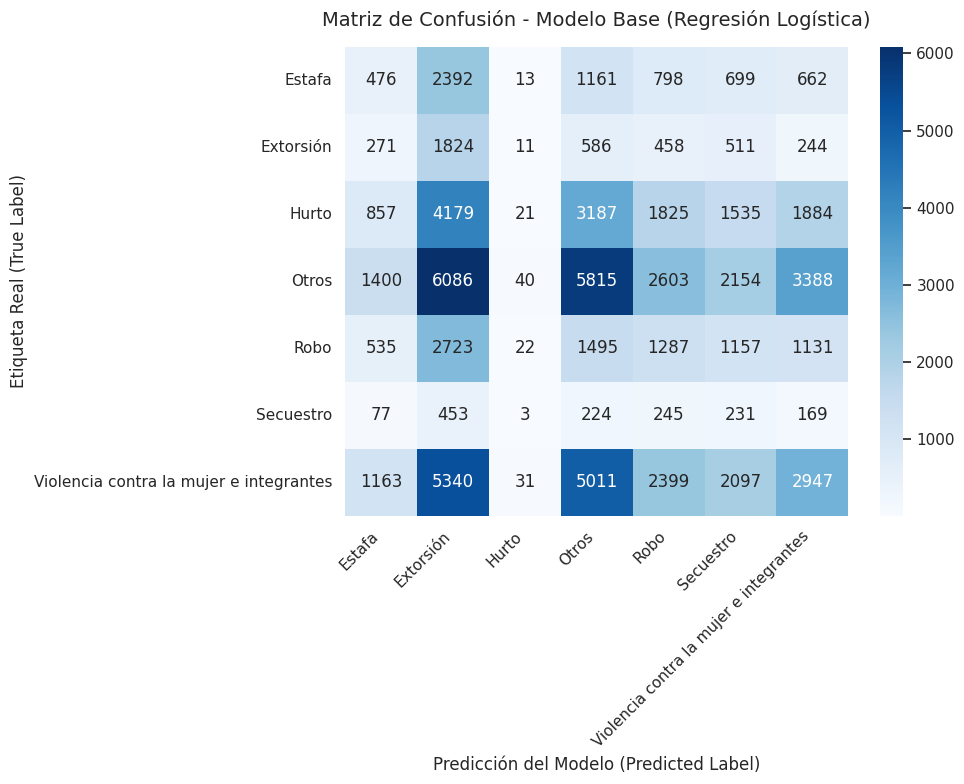

/tmp/ipykernel_836/4178534328.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='viridis')


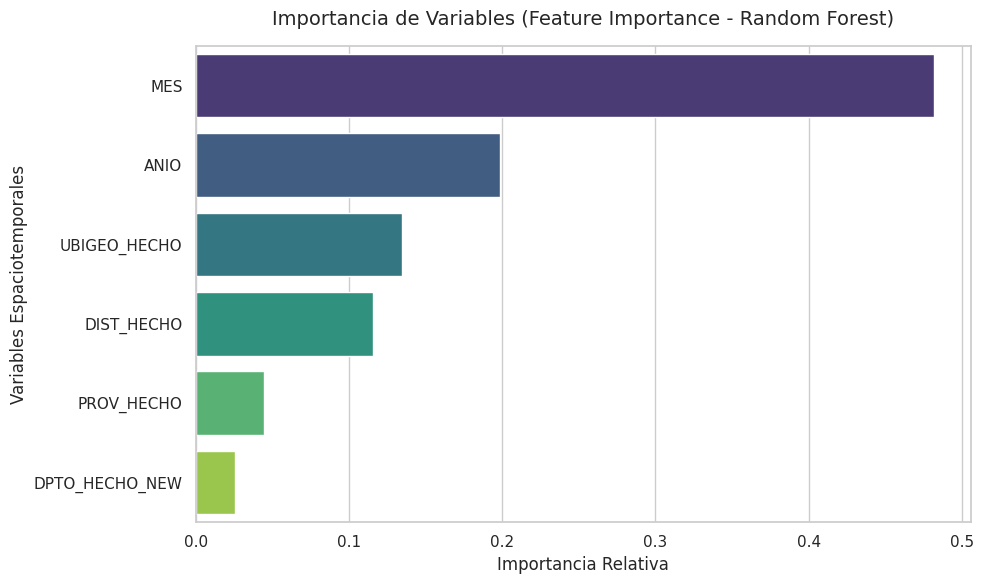

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print(" Generando Gráficos ")

# 1. Matriz de Confusión
# Evaluamos el Baseline porque fue el que obtuvo mejor rendimiento global
cm = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Matriz de Confusión - Modelo Base (Regresión Logística)', fontsize=14, pad=15)
plt.ylabel('Etiqueta Real (True Label)', fontsize=12)
plt.xlabel('Predicción del Modelo (Predicted Label)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Interpretabilidad / Feature Importance
# Usamos Random Forest para extraer qué variable importó más en la predicción
importances = rf_modelo.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
plt.title('Importancia de Variables (Feature Importance - Random Forest)', fontsize=14, pad=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variables Espaciotemporales', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
!pip install gradio

In [13]:
import gradio as gr
import pandas as pd

# Función que conecta la interfaz visual el modelo
def predecir_delito(anio, mes, departamento, provincia, distrito):
    try:
        # 1. Creamos la matriz con las coordenadas ingresadas
        input_data = pd.DataFrame({
            'ANIO': [int(anio)],
            'MES': [int(mes)],
            'DPTO_HECHO_NEW': [str(departamento).upper()],
            'PROV_HECHO': [str(provincia).upper()],
            'DIST_HECHO': [str(distrito).upper()],
            'UBIGEO_HECHO': [0]
        })

        # 2. Aplicar tus LabelEncoders exactos
        input_encoded = input_data.copy()
        input_encoded['DPTO_HECHO_NEW'] = le_dpto.transform(input_encoded['DPTO_HECHO_NEW'])
        input_encoded['PROV_HECHO'] = le_prov.transform(input_encoded['PROV_HECHO'])
        input_encoded['DIST_HECHO'] = le_dist.transform(input_encoded['DIST_HECHO'])

        # 3. Escalar con StandardScaler
        input_scaled = scaler.transform(input_encoded)

        # 4. Inferencia con el Modelo Base (Regresión Logística)
        prediccion_numerica = modelo_base.predict(input_scaled)

        # 5. Decodificar el tensor matemático a la tipología penal
        resultado_texto = le_target.inverse_transform(prediccion_numerica)
        resultado_final = resultado_texto[0]

        return f" Alerta Predictiva: Alta probabilidad de {resultado_final}"

    except ValueError:
        return "Error: Verifique que el Departamento, Provincia o Distrito existan en el registro histórico y estén bien escritos."
    except Exception as e:
        return f"Error interno del servidor: {str(e)}"

# Despliegue de la interfaz gráfica
interfaz = gr.Interface(
    fn=predecir_delito,
    inputs=[
        gr.Slider(2018, 2030, step=1, label="Año"),
        gr.Slider(1, 12, step=1, label="Mes"),
        gr.Textbox(label="Departamento (Ej. LIMA METROPOLITANA)"),
        gr.Textbox(label="Provincia (Ej. LIMA)"),
        gr.Textbox(label="Distrito (Ej. SAN MIGUEL)")
    ],
    outputs=gr.Textbox(label="Resultado de la Inteligencia Artificial"),
    title="Prototipo de Policiamiento Predictivo (SIDPOL)",
    description="Ingrese las coordenadas espaciotemporales para que el algoritmo clasifique la tipología delictiva de mayor riesgo."
)

interfaz.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d570d9439c781b6d73.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://d570d9439c781b6d73.gradio.live
